In [4]:
from google.colab import files
uploaded = files.upload()



Saving Churn_Modelling.csv to Churn_Modelling.csv


In [22]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD

In [23]:
df = pd.read_csv('/content/Churn_Modelling.csv')

In [24]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [25]:
new_data = df[['CustomerId' , 'Surname' , 'CreditScore' , 'IsActiveMember']]
print(new_data.head())

   CustomerId   Surname  CreditScore  IsActiveMember
0    15634602  Hargrave          619               1
1    15647311      Hill          608               1
2    15619304      Onio          502               0
3    15701354      Boni          699               0
4    15737888  Mitchell          850               1


In [27]:

# Remove unnecessary columns
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

# Encode categorical columns
le_gender = LabelEncoder()
df['Gender'] = le_gender.fit_transform(df['Gender'])

# One-hot encoding for Geography
df = pd.get_dummies(df, columns=['Geography'], drop_first=True)

# Features and target
X = df.drop('Exited', axis=1)
y = df['Exited']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Feature scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [35]:
# ============================================
# STEP 5: Build ANN Model
# ============================================

model_momentum = Sequential()

model_momentum.add(Dense(11, activation='relu', input_dim=X_train.shape[1]))
model_momentum.add(Dense(11, activation='relu'))
model_momentum.add(Dense(1, activation='sigmoid'))

# SGD with Momentum
optimizer_momentum = SGD(
    learning_rate=0.01,
    momentum=0.9
)

model_momentum.compile(
    optimizer=optimizer_momentum,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train Model
history_momentum = model_momentum.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.7713 - loss: 0.5033 - val_accuracy: 0.8100 - val_loss: 0.4390
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8147 - loss: 0.4341 - val_accuracy: 0.8331 - val_loss: 0.4086
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8252 - loss: 0.4140 - val_accuracy: 0.8394 - val_loss: 0.3933
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8403 - loss: 0.3920 - val_accuracy: 0.8525 - val_loss: 0.3790
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8517 - loss: 0.3678 - val_accuracy: 0.8569 - val_loss: 0.3589
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8533 - loss: 0.3556 - val_accuracy: 0.8650 - val_loss: 0.3516
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8570 - loss: 0.3487 - val_accuracy: 0.8581 - val_loss: 0.3503
Epoch 8/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8583 - loss: 0.3459 - val_accuracy: 0.8587 - va

In [29]:
# ============================================
# STEP 6: Build ANN with Nesterov Momentum
# ============================================

model_nesterov = Sequential()

model_nesterov.add(Dense(11, activation='relu', input_dim=X_train.shape[1]))
model_nesterov.add(Dense(11, activation='relu'))
model_nesterov.add(Dense(1, activation='sigmoid'))

# SGD with Nesterov Momentum
optimizer_nesterov = SGD(
    learning_rate=0.01,
    momentum=0.9,
    nesterov=True
)

model_nesterov.compile(
    optimizer=optimizer_nesterov,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train Model
history_nesterov = model_nesterov.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7739 - loss: 0.5155 - val_accuracy: 0.8100 - val_loss: 0.4461
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8072 - loss: 0.4460 - val_accuracy: 0.8294 - val_loss: 0.4161
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8206 - loss: 0.4210 - val_accuracy: 0.8356 - val_loss: 0.3973
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8298 - loss: 0.3966 - val_accuracy: 0.8462 - val_loss: 0.3788
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8428 - loss: 0.3735 - val_accuracy: 0.8544 - val_loss: 0.3620
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8498 - loss: 0.3585 - val_accuracy: 0.8562 - val_loss: 0.3516
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8581 - loss: 0.3528 - val_accuracy: 0.8569 - val_loss: 0.3477
Epoch 8/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8542 - loss: 0.3475 - val_accuracy: 0.

In [30]:
# ============================================
# STEP 7: Evaluate Models
# ============================================

print("Momentum Model Accuracy:")
print(model_momentum.evaluate(X_test, y_test))

print("\nNesterov Model Accuracy:")
print(model_nesterov.evaluate(X_test, y_test))

Momentum Model Accuracy:
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8540 - loss: 0.3353
[0.3352699279785156, 0.8539999723434448]

Nesterov Model Accuracy:
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8625 - loss: 0.3395
[0.33954355120658875, 0.862500011920929]


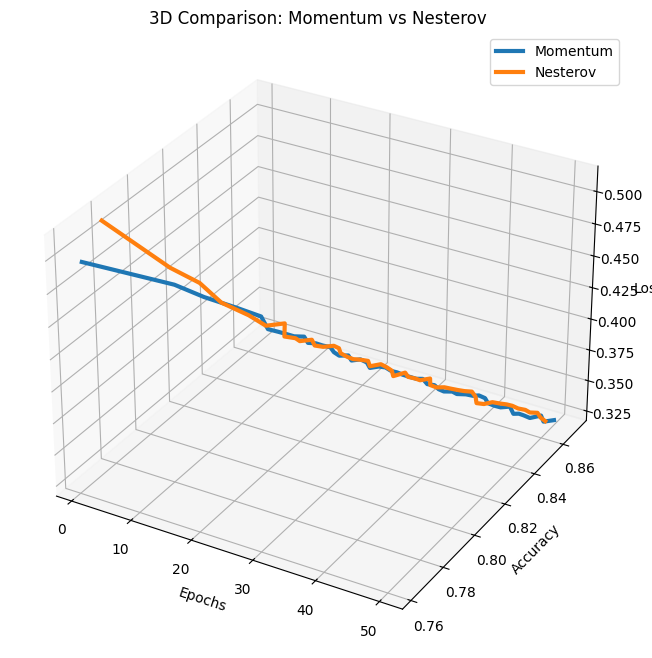

In [32]:
# ============================================
# 3D GRAPH FOR MOMENTUM vs NESTEROV
# ============================================

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Epoch values
epochs = range(1, len(history_momentum.history['accuracy']) + 1)

# Momentum data
momentum_acc = history_momentum.history['accuracy']
momentum_loss = history_momentum.history['loss']

# Nesterov data
nesterov_acc = history_nesterov.history['accuracy']
nesterov_loss = history_nesterov.history['loss']

# Create figure
fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot(111, projection='3d')

# Plot Momentum
ax.plot(
    epochs,
    momentum_acc,
    momentum_loss,
    label='Momentum',
    linewidth=3
)

# Plot Nesterov
ax.plot(
    epochs,
    nesterov_acc,
    nesterov_loss,
    label='Nesterov',
    linewidth=3
)

# Labels
ax.set_xlabel('Epochs')
ax.set_ylabel('Accuracy')
ax.set_zlabel('Loss')

ax.set_title('3D Comparison: Momentum vs Nesterov')

ax.legend()

plt.show()

In [34]:
# Install plotly if needed
!pip install plotly -q

import plotly.graph_objects as go
import numpy as np

# Epochs
epochs = np.arange(1, len(history_momentum.history['accuracy']) + 1)

# Momentum data
momentum_acc = history_momentum.history['accuracy']
momentum_loss = history_momentum.history['loss']

# Nesterov data
nesterov_acc = history_nesterov.history['accuracy']
nesterov_loss = history_nesterov.history['loss']

# Create 3D figure
fig = go.Figure()

# Momentum line
fig.add_trace(go.Scatter3d(
    x=epochs,
    y=momentum_acc,
    z=momentum_loss,
    mode='lines+markers',
    name='Momentum'
))

# Nesterov line
fig.add_trace(go.Scatter3d(
    x=epochs,
    y=nesterov_acc,
    z=nesterov_loss,
    mode='lines+markers',
    name='Nesterov'
))

# Layout
fig.update_layout(
    title='3D Optimizer Visualization',
    scene=dict(
        xaxis_title='Epochs',
        yaxis_title='Accuracy',
        zaxis_title='Loss'
    ),
    height=700,
    width=1000
)

# Show graph
fig.show()